ANOVA analysis - vertical difference

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, bartlett, anderson, normaltest

import pingouin as pg
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
# normality and homogeneity of variance tests for ANOVA assumptions
def check_anova_assumptions(df, group_col, metric_col, group_order=None):
    if group_order is None:
        group_order = df[group_col].unique()

    print(f"\n=== Normality test (D’Agostino and Pearson) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = normaltest(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Shapiro-Wilk) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = shapiro(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Anderson-Darling) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        result = anderson(data)
        stat = result.statistic
        crit_5 = result.critical_values[2]
        interpretation = "OK normal" if stat < crit_5 else "not normal"
        print(f"{group.ljust(25)}:\tA² = {stat:.4f},\t5% critical = {crit_5:.4f}\t→\t{interpretation}")

    print(f"\n=== Homogeneity of variance tests for {metric_col} ===")
    groups = [df[df[group_col] == group][metric_col] for group in group_order]

    stat_levene, p_levene = levene(*groups)
    result_levene = "OK equal variances" if p_levene > 0.05 else "unequal variances"
    print(f"Levene’s test  : p = {p_levene:.4f}\t→\t{result_levene}")

    stat_bartlett, p_bartlett = bartlett(*groups)
    result_bartlett = "OK equal variances" if p_bartlett > 0.05 else "unequal variances"
    print(f"Bartlett’s test: p = {p_bartlett:.4f}\t→\t{result_bartlett}")

    # Brown–Forsythe test (Levene with center='median')
    stat_bf, p_bf = levene(*groups, center='median')
    result_bf = "OK equal variances" if p_bf > 0.05 else "unequal variances"
    print(f"Brown–Forsythe : p = {p_bf:.4f}\t→\t{result_bf}")

In [3]:
def interpret_eta2(x: float) -> str:
    if x < 0.01:
        return "negligible"
    elif x < 0.06:
        return "small"
    elif x < 0.14:
        return "medium"
    else:
        return "large"

def interpret_d_like(x: float) -> str:
    ax = abs(x)
    if ax < 0.2:
        return "negligible"
    elif ax < 0.5:
        return "small"
    elif ax < 0.8:
        return "medium"
    else:
        return "large"

In [4]:
# ANOVA with eta squared, Games-Howell posthoc, and pairwise Hedges g effect sizes
def run_anova_full(df, group_col, metric_col, show_ci=True):
    # ===== Welch ANOVA =====
    print(f"\n=== Welch ANOVA for {metric_col} ===")
    welch = pg.welch_anova(dv=metric_col, between=group_col, data=df)
    print(welch.to_string(index=False))

    # Overall effect size (np2) interpretation
    if "np2" in welch.columns:
        np2 = float(welch.loc[0, "np2"])
        print(f"\nEffect size (partial η², np2) = {np2:.4f} → {interpret_eta2(np2)} effect")
    else:
        np2 = None
        print("\nEffect size: np2 not provided by Welch ANOVA output.")

    # ===== Games-Howell post-hoc =====
    print(f"\n=== Games-Howell post-hoc test for {metric_col} ===")
    gh = pg.pairwise_gameshowell(dv=metric_col, between=group_col, data=df).copy()
    print(gh.to_string(index=False))

    # ===== Pairwise effect sizes =====
    print(f"\n=== Pairwise effect sizes for {metric_col} (Hedges' g) ===")
    group_labels = list(pd.unique(df[group_col]))
    label_width = max(len(str(g)) for g in group_labels) + 2

    for g1, g2 in combinations(group_labels, 2):
        x = df.loc[df[group_col] == g1, metric_col].to_numpy()
        y = df.loc[df[group_col] == g2, metric_col].to_numpy()

        g = float(pg.compute_effsize(x, y, eftype="hedges"))
        effect = interpret_d_like(g)

        line = (
            f"{str(g1).ljust(label_width)} vs {str(g2).ljust(label_width)}:"
            f" g = {g:.4f} → {effect} effect"
        )

        if show_ci:
            ci = pg.compute_bootci(
                x, y,
                func=lambda a, b: pg.compute_effsize(a, b, eftype="hedges"),
                confidence=0.95,
                method="percentile",
            )
            line += f"   95% CI [{ci[0]:.4f}, {ci[1]:.4f}]"

        print(line)

## Time independent - Left

In [5]:
model = "time independent Left CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_room2_lefttop_state_timeindep_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_room2_leftlow_state_timeindep_co2.csv")
dual_co2_only = pd.read_csv("../_timeindep_results_raw/case_room2_left_state_timeindep_co2only.csv")
dual_VD = pd.read_csv("../_timeindep_results_raw/case_room2_left_state_timeindep_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeindep_results_raw/case_room2_left_state_timeindep_VDco2.csv")

In [6]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.956233,0.011638,0.923636,0.949091,0.956364,0.963636,0.981818
f1_weighted,250.0,0.955903,0.011912,0.922610,0.948425,0.956042,0.963792,0.981908
balanced_acc,250.0,0.926331,0.022791,0.851303,0.911999,0.928540,0.942975,0.974694
auc,250.0,0.989402,0.004436,0.974419,0.986768,0.989717,0.992726,0.998963
model_weights.random_forest,250.0,2.717388,0.364399,1.626271,2.507636,2.727103,2.960892,3.877464
model_weights.bagging_svc,250.0,1.783660,0.324613,0.748721,1.571396,1.796431,2.008731,2.535149
model_weights.bagging_knn,250.0,0.925843,0.291123,0.008364,0.732152,0.946365,1.113242,1.830793
model_weights.gradient_boosting,250.0,1.121098,0.448089,-0.077188,0.846576,1.136105,1.447630,2.266582


In [7]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.965891,0.009801,0.941818,0.960000,0.967273,0.970909,0.989091
f1_weighted,250.0,0.965689,0.009918,0.940520,0.959854,0.966873,0.971158,0.989139
balanced_acc,250.0,0.942014,0.018563,0.877889,0.931743,0.942208,0.956269,0.984541
auc,250.0,0.994733,0.002408,0.984242,0.993351,0.995050,0.996424,0.998937
model_weights.random_forest,250.0,2.207619,0.375639,1.277377,1.977333,2.210079,2.425812,3.536211
model_weights.bagging_svc,250.0,0.812424,0.408434,-0.240708,0.537036,0.830167,1.077966,1.996014
model_weights.bagging_knn,250.0,2.001033,0.330298,0.940056,1.781288,1.982309,2.210934,2.992711
model_weights.gradient_boosting,250.0,1.933906,0.379613,0.959709,1.720405,1.943544,2.174397,3.328599


In [8]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.963055,0.010468,0.930909,0.956364,0.963636,0.970909,0.985455
f1_weighted,250.0,0.962758,0.010643,0.930694,0.955846,0.963398,0.970530,0.985455
balanced_acc,250.0,0.936003,0.020171,0.877889,0.922944,0.937217,0.949681,0.980193
auc,250.0,0.994088,0.002597,0.986294,0.992641,0.994488,0.996003,0.998827
model_weights.random_forest,250.0,2.445934,0.354724,1.399689,2.236938,2.468104,2.691102,3.514547
model_weights.bagging_svc,250.0,1.368678,0.349813,-0.004288,1.173029,1.365350,1.613258,2.250911
model_weights.bagging_knn,250.0,1.775690,0.348001,0.566115,1.546757,1.744984,1.998819,2.936204
model_weights.gradient_boosting,250.0,1.069494,0.490930,-0.097177,0.712100,1.068244,1.430001,2.338477


In [9]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.923985,0.014798,0.887273,0.912727,0.923636,0.934545,0.960000
f1_weighted,250.0,0.923150,0.015222,0.886135,0.912029,0.923888,0.934447,0.959858
balanced_acc,250.0,0.873135,0.026704,0.797128,0.855544,0.873884,0.893718,0.934812
auc,250.0,0.961419,0.011415,0.917597,0.952833,0.962717,0.969592,0.986996
model_weights.random_forest,250.0,2.549819,0.442949,1.339158,2.255400,2.549885,2.830120,3.780680
model_weights.bagging_svc,250.0,1.430949,0.365822,0.271460,1.166396,1.431312,1.668328,2.341953
model_weights.bagging_knn,250.0,0.301130,0.265399,-0.532832,0.122831,0.291171,0.458738,1.500261
model_weights.gradient_boosting,250.0,0.110317,0.454186,-1.144257,-0.209048,0.103087,0.408831,1.573454


In [10]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,1.867500e+02,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,1.867500e+02,249.000000
accuracy,250.0,0.961920,0.010239,0.934545,0.956364,0.963636,9.672727e-01,0.992727
f1_weighted,250.0,0.961567,0.010451,0.933120,0.955596,0.962973,9.673223e-01,0.992727
balanced_acc,250.0,0.933021,0.020136,0.877889,0.920908,0.934082,9.472156e-01,0.988934
auc,250.0,0.993800,0.002643,0.985640,0.991854,0.994308,9.955912e-01,0.998744
model_weights.random_forest,250.0,3.065126,0.392120,1.776760,2.803185,3.048167,3.328943e+00,4.347991
model_weights.bagging_svc,250.0,0.440642,0.359767,-0.494046,0.222137,0.445337,6.572884e-01,1.667625
model_weights.bagging_knn,250.0,2.232499,0.292649,1.285131,2.043798,2.239078,2.419057e+00,3.090349
model_weights.gradient_boosting,250.0,1.137122,0.506918,-0.317480,0.791185,1.148139,1.473066e+00,3.266411


In [11]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1_weighted   1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [12]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.967273,0.956364,0.952727,0.934545,0.974545
f1_weighted,0.967154,0.956364,0.95258,0.932665,0.974177
balanced_acc,0.943821,0.93087,0.926789,0.874497,0.950755
auc,0.992776,0.991118,0.992467,0.976259,0.998963
x,0,0,0,0,0
x_jitter,0.088173,0.091062,0.055842,-0.033865,0.030301


### plot

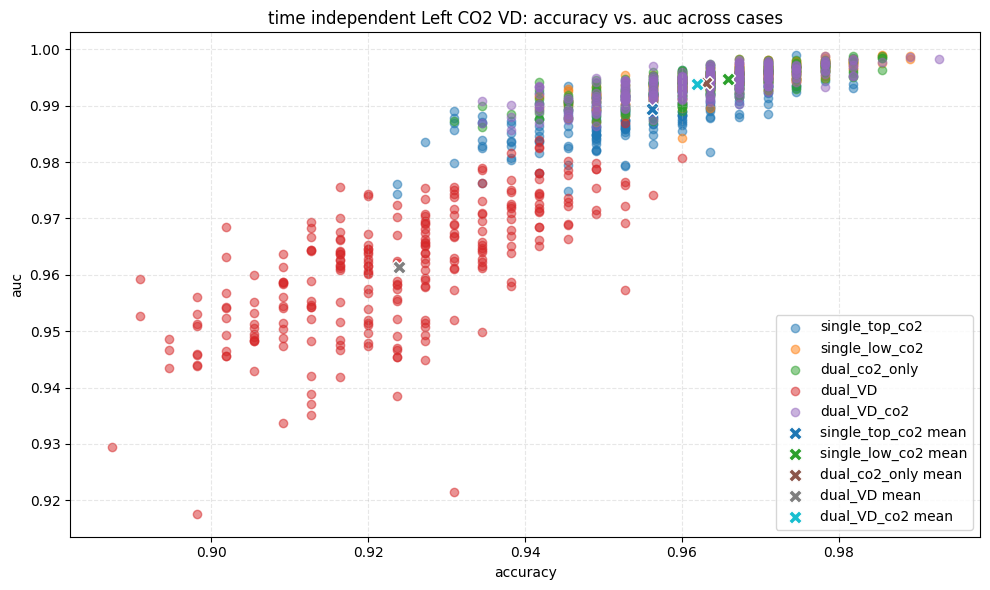

In [13]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

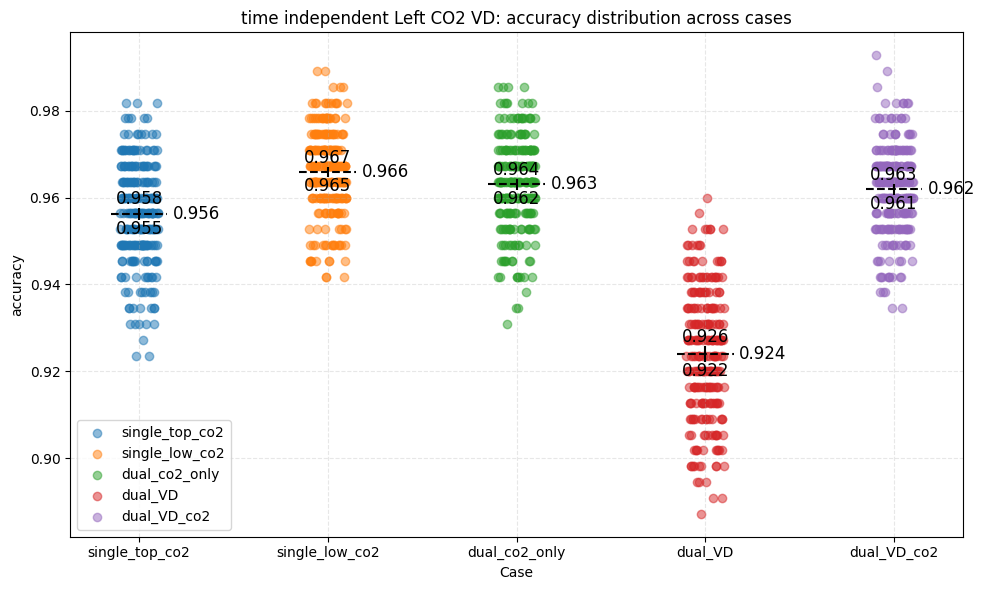

In [14]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

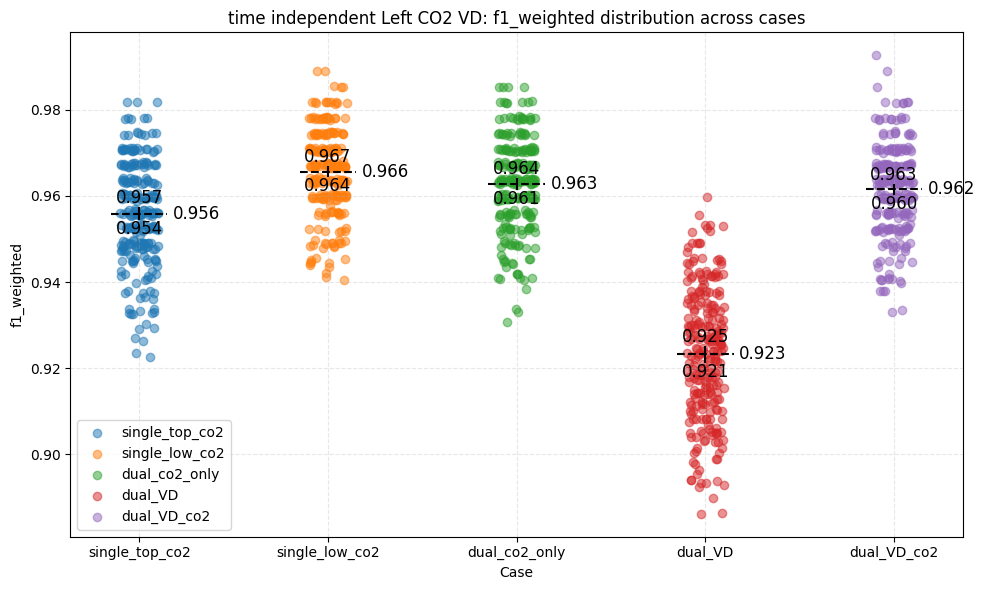

In [15]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

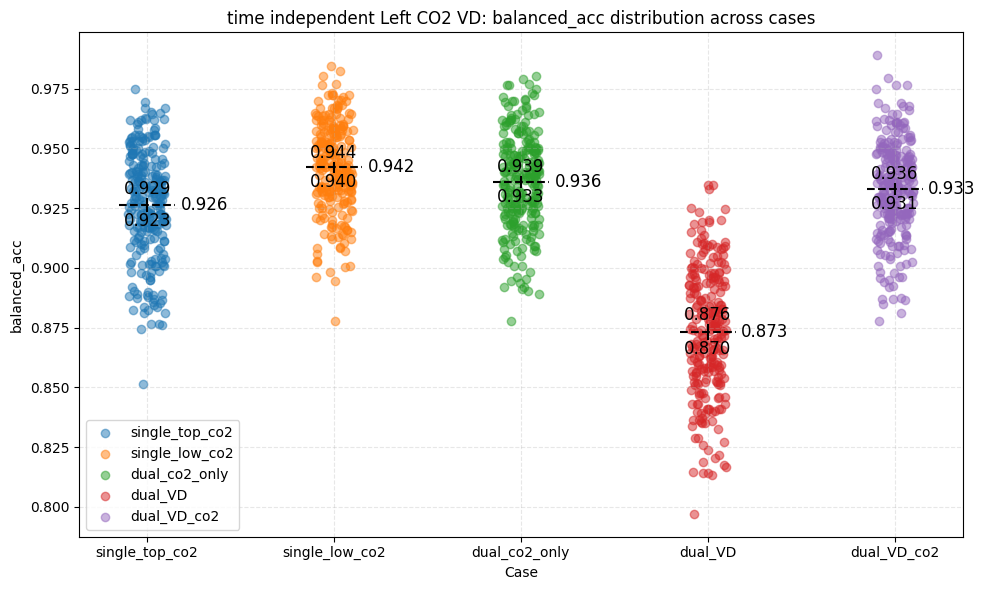

In [16]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

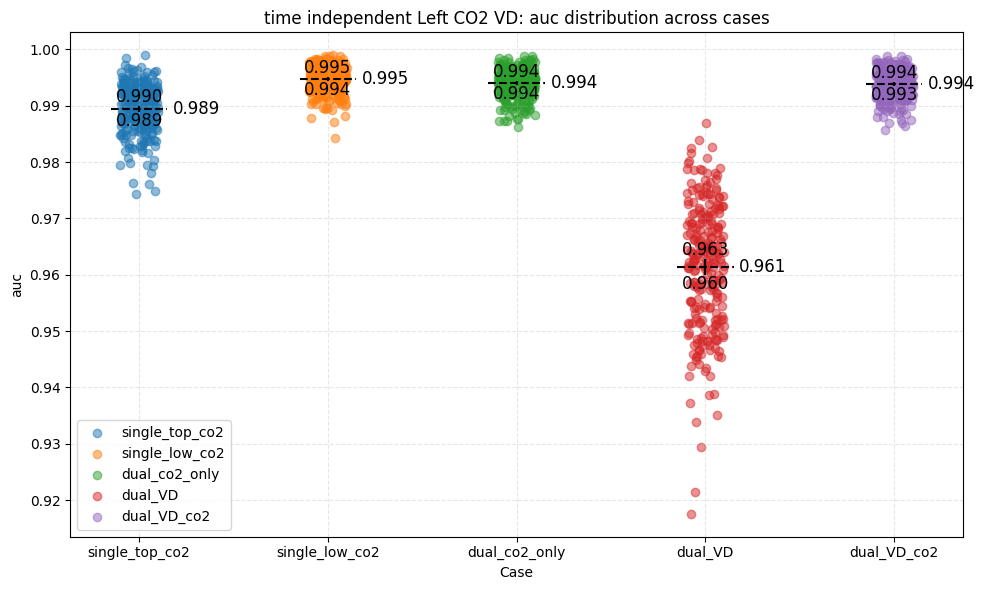

In [17]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent Left CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.2340	→	OK normal
single_low_co2           :	p = 0.1545	→	OK normal
dual_co2_only            :	p = 0.0988	→	OK normal
dual_VD                  :	p = 0.0567	→	OK normal
dual_VD_co2              :	p = 0.5778	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.0055	→	not normal
single_low_co2           :	p = 0.0004	→	not normal
dual_co2_only            :	p = 0.0011	→	not normal
dual_VD                  :	p = 0.0432	→	not normal
dual_VD_co2              :	p = 0.0058	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 1.3769,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 2.0808,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 1.9007,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.8844,	5% critical = 0.7750	→	not normal


In [19]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent Left CO2 VD

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
single_top_co2           :	p = 0.1612	→	OK normal
single_low_co2           :	p = 0.1364	→	OK normal
dual_co2_only            :	p = 0.0940	→	OK normal
dual_VD                  :	p = 0.0611	→	OK normal
dual_VD_co2              :	p = 0.4607	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
single_top_co2           :	p = 0.0250	→	not normal
single_low_co2           :	p = 0.0036	→	not normal
dual_co2_only            :	p = 0.0088	→	not normal
dual_VD                  :	p = 0.2673	→	OK normal
dual_VD_co2              :	p = 0.0490	→	not normal

=== Normality test (Anderson-Darling) for f1_weighted ===
single_top_co2           :	A² = 0.8069,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 1.3983,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 1.2081,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.3504,	5% critical = 0.7750	→	OK 

In [20]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent Left CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.0272	→	not normal
single_low_co2           :	p = 0.0655	→	OK normal
dual_co2_only            :	p = 0.3146	→	OK normal
dual_VD                  :	p = 0.2491	→	OK normal
dual_VD_co2              :	p = 0.3595	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.0031	→	not normal
single_low_co2           :	p = 0.0654	→	OK normal
dual_co2_only            :	p = 0.3802	→	OK normal
dual_VD                  :	p = 0.4074	→	OK normal
dual_VD_co2              :	p = 0.4335	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 1.0970,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 0.5982,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.2323,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.3213,	5% critical = 0.7750	→	OK n

In [21]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent Left CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.0001	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0003	→	not normal
dual_VD                  :	p = 0.0011	→	not normal
dual_VD_co2              :	p = 0.0024	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.0001	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0009	→	not normal
dual_VD_co2              :	p = 0.0001	→	not normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 1.4416,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 2.0246,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 2.3770,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 1.0250,	5% critical = 0.7750	→	not normal
dual_VD_co

### ANOVA

In [22]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent Left CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 620.035904 394.607919 8.542221e-169 0.642786

Effect size (partial η², np2) = 0.6428 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.923985 0.961920 -0.037935 0.001138 -33.330632 442.966481 1.502132e-13 -2.976690
       dual_VD  dual_co2_only 0.923985 0.963055 -0.039069 0.001146 -34.078874 448.301496 5.251355e-14 -3.043514
       dual_VD single_low_co2 0.923985 0.965891 -0.041905 0.001123 -37.329360 432.200688 5.773160e-14 -3.333809
       dual_VD single_top_co2 0.923985 0.956233 -0.032247 0.001191 -27.082588 471.794037 9.636736e-14 -2.418690
   dual_VD_co2  dual_co2_only 0.961920 0.963055 -0.001135 0.000926  -1.225029 497.756573 7.367825e-01 -0.109405
   dual_VD_co2 single_low_co2 0.961920 0.96

In [23]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent Left CO2 VD

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 619.876196 385.390106 1.676455e-166 0.639262

Effect size (partial η², np2) = 0.6393 → large effect

=== Games-Howell post-hoc test for f1_weighted ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.923150 0.961567 -0.038417 0.001168 -32.897906 441.069718 2.664535e-13 -2.938045
       dual_VD  dual_co2_only 0.923150 0.962758 -0.039607 0.001175 -33.717173 445.499380 4.707346e-14 -3.011212
       dual_VD single_low_co2 0.923150 0.965689 -0.042538 0.001149 -37.021241 428.134759 2.298162e-13 -3.306291
       dual_VD single_top_co2 0.923150 0.955903 -0.032753 0.001222 -26.792389 470.804022 2.633449e-13 -2.392773
   dual_VD_co2  dual_co2_only 0.961567 0.962758 -0.001190 0.000943  -1.261641 497.834597 7.148739e-01 -0.112675
   dual_VD_co2 single_low_co2 0.96156

In [24]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent Left CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F         p-unc     np2
  case      4 620.415611 312.183799 5.507247e-147 0.56764

Effect size (partial η², np2) = 0.5676 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.873135 0.933021 -0.059886 0.002115 -28.311540 462.974644 0.000000e+00 -2.528446
       dual_VD  dual_co2_only 0.873135 0.936003 -0.062868 0.002117 -29.702114 463.359889 5.505596e-13 -2.652635
       dual_VD single_low_co2 0.873135 0.942014 -0.068879 0.002057 -33.486800 444.085595 1.509903e-14 -2.990637
       dual_VD single_top_co2 0.873135 0.926331 -0.053196 0.002220 -23.957645 486.000457 3.305134e-13 -2.139608
   dual_VD_co2  dual_co2_only 0.933021 0.936003 -0.002982 0.001803  -1.654070 497.998452 4.635802e-01 -0.147722
   dual_VD_co2 single_low_co2 0.93302

In [25]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent Left CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 608.364029 564.019716 5.061561e-203 0.828554

Effect size (partial η², np2) = 0.8286 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.961419 0.993800 -0.032380 0.000741 -43.695220 275.613380 0.000000e+00 -3.902330
       dual_VD  dual_co2_only 0.961419 0.994088 -0.032668 0.000740 -44.122025 274.711398 7.149836e-14 -3.940448
       dual_VD single_low_co2 0.961419 0.994733 -0.033314 0.000738 -45.150621 271.109171 0.000000e+00 -4.032309
       dual_VD single_top_co2 0.961419 0.989402 -0.027983 0.000775 -36.127288 322.537726 0.000000e+00 -3.226454
   dual_VD_co2  dual_co2_only 0.993800 0.994088 -0.000288 0.000234  -1.228679 497.850411 7.346246e-01 -0.109731
   dual_VD_co2 single_low_co2 0.993800 0.994733 -0.00

## Time series - Left

In [26]:
model = "time series Left CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_room2_lefttop_state_timeseries_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_room2_leftlow_state_timeseries_co2.csv")
dual_co2_only = pd.read_csv("../_timeseries_results_raw/case_room2_left_state_timeseries_co2only.csv")
dual_VD = pd.read_csv("../_timeseries_results_raw/case_room2_left_state_timeseries_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeseries_results_raw/case_room2_left_state_timeseries_VDco2.csv")

In [27]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.866459,0.041479,0.797665,0.821012,0.891051,0.898833,0.933852
f1,250.0,0.824220,0.060710,0.714286,0.755319,0.862745,0.873477,0.910995
balanced_acc,250.0,0.870676,0.052005,0.777503,0.810112,0.904644,0.912220,0.936462
auc,250.0,0.945296,0.024295,0.888406,0.919401,0.956818,0.968083,0.978722
feature_importance.lefttop_CO2_scaled,250.0,0.004825,0.007598,-0.011284,-0.000681,0.003891,0.008463,0.040078
feature_importance.lefttop_CO2_fd1_scaled,250.0,0.133295,0.109981,0.002724,0.019455,0.159533,0.231420,0.342412
feature_importance.lefttop_CO2_fd2_scaled,250.0,0.108288,0.089145,0.001556,0.018385,0.115953,0.183755,0.309728
feature_importance.lefttop_CO2_fd3_scaled,250.0,0.071795,0.063508,-0.001556,0.014105,0.059728,0.118288,0.261089


In [28]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.911346,0.019635,0.856031,0.902724,0.914397,0.926070,0.957198
f1,250.0,0.888191,0.022335,0.826291,0.877148,0.891192,0.903553,0.943005
balanced_acc,250.0,0.926389,0.016733,0.878261,0.919433,0.930303,0.936989,0.964262
auc,250.0,0.978894,0.015676,0.875758,0.978821,0.982938,0.985935,0.992424
feature_importance.leftlow_CO2_scaled,250.0,0.115314,0.075288,0.005837,0.055058,0.104280,0.162646,0.337743
feature_importance.leftlow_CO2_fd1_scaled,250.0,0.129121,0.045750,-0.004280,0.114883,0.135214,0.156420,0.226459
feature_importance.leftlow_CO2_fd2_scaled,250.0,0.108487,0.042472,-0.010895,0.088327,0.111284,0.134922,0.212062
feature_importance.leftlow_CO2_fd3_scaled,250.0,0.078954,0.038190,-0.011673,0.056615,0.082101,0.100681,0.240856


In [29]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.864420,0.038811,0.712062,0.852140,0.875486,0.887160,0.929961
f1,250.0,0.783210,0.096141,0.362069,0.752070,0.816583,0.843602,0.909091
balanced_acc,250.0,0.834791,0.065750,0.605040,0.801762,0.849868,0.880031,0.940646
auc,250.0,0.964773,0.009585,0.904941,0.961792,0.966370,0.970076,0.981291
feature_importance.leftlow_CO2_scaled,250.0,0.080338,0.098086,-0.019455,0.029183,0.046498,0.085895,0.501167
feature_importance.leftlow_CO2_fd1_scaled,250.0,0.014697,0.021328,-0.022568,0.003696,0.011089,0.019455,0.159144
feature_importance.leftlow_CO2_fd2_scaled,250.0,0.016632,0.022434,-0.031907,0.005837,0.011868,0.023735,0.163424
feature_importance.leftlow_CO2_fd3_scaled,250.0,0.017444,0.028505,-0.019066,0.004280,0.011673,0.022082,0.305058


In [30]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.856940,0.018899,0.788845,0.852590,0.864542,0.864542,0.916335
f1,250.0,0.827135,0.029880,0.666667,0.820755,0.842593,0.842593,0.892308
balanced_acc,250.0,0.874578,0.027991,0.744018,0.865686,0.890792,0.890792,0.922512
auc,250.0,0.918159,0.016198,0.799084,0.913864,0.920837,0.927656,0.949959
feature_importance.left_CO2_vd_scaled,250.0,0.148261,0.100847,-0.042231,0.049801,0.153586,0.229781,0.376096
feature_importance.left_CO2_vd_fd1_scaled,250.0,0.271163,0.086930,0.006773,0.225398,0.291434,0.336155,0.407570
feature_importance.left_CO2_vd_fd2_scaled,250.0,0.281391,0.095206,0.022709,0.222908,0.310956,0.350498,0.419920
feature_importance.left_CO2_vd_fd3_scaled,250.0,0.280245,0.098171,-0.007171,0.227988,0.306972,0.354582,0.424701


In [31]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.868167,0.023956,0.690377,0.853556,0.866109,0.885983,0.924686
f1,250.0,0.838498,0.036045,0.447761,0.828283,0.843308,0.854345,0.900000
balanced_acc,250.0,0.873130,0.027073,0.622227,0.864186,0.876941,0.887866,0.917702
auc,250.0,0.957553,0.013837,0.858104,0.951882,0.959073,0.965765,0.979074
feature_importance.left_CO2_vd_scaled,250.0,0.029456,0.051898,-0.038075,0.001360,0.010669,0.031904,0.278243
feature_importance.left_CO2_vd_fd1_scaled,250.0,-0.000792,0.008777,-0.028033,-0.005858,-0.001255,0.004603,0.035146
feature_importance.left_CO2_vd_fd2_scaled,250.0,-0.001739,0.011386,-0.040167,-0.007950,-0.000837,0.005021,0.043515
feature_importance.left_CO2_vd_fd3_scaled,250.0,-0.000049,0.012705,-0.032636,-0.006172,0.000209,0.005858,0.076151


In [32]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1            1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [33]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.902724,0.898833,0.801556,0.891051,0.902724
f1,0.874372,0.871287,0.724324,0.861386,0.875622
balanced_acc,0.91222,0.911594,0.785343,0.903129,0.914625
auc,0.961989,0.967918,0.917062,0.959947,0.948155
x,0,0,0,0,0
x_jitter,-0.077862,-0.001504,-0.063195,0.092112,0.00778


### plot

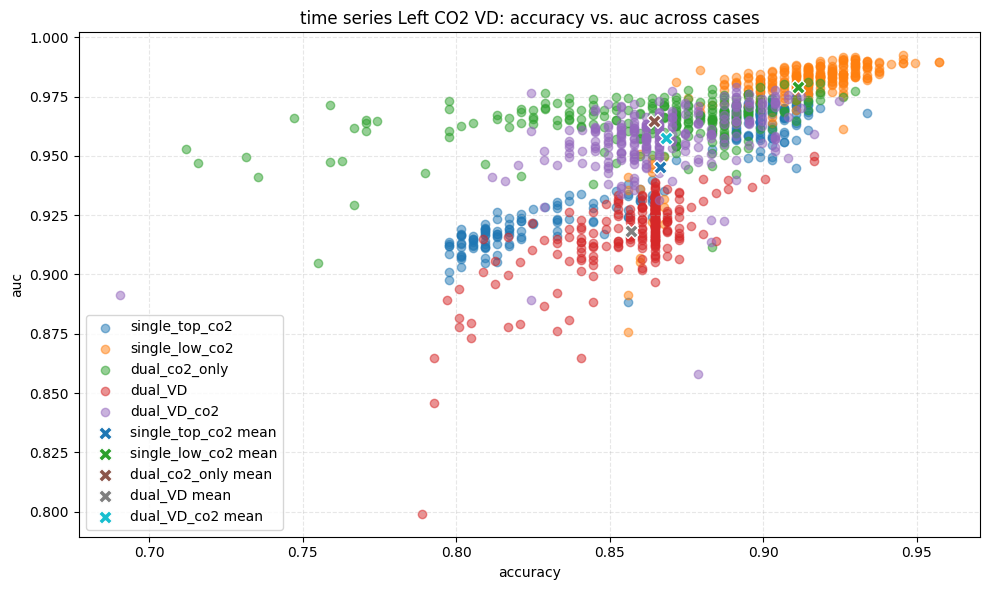

In [34]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

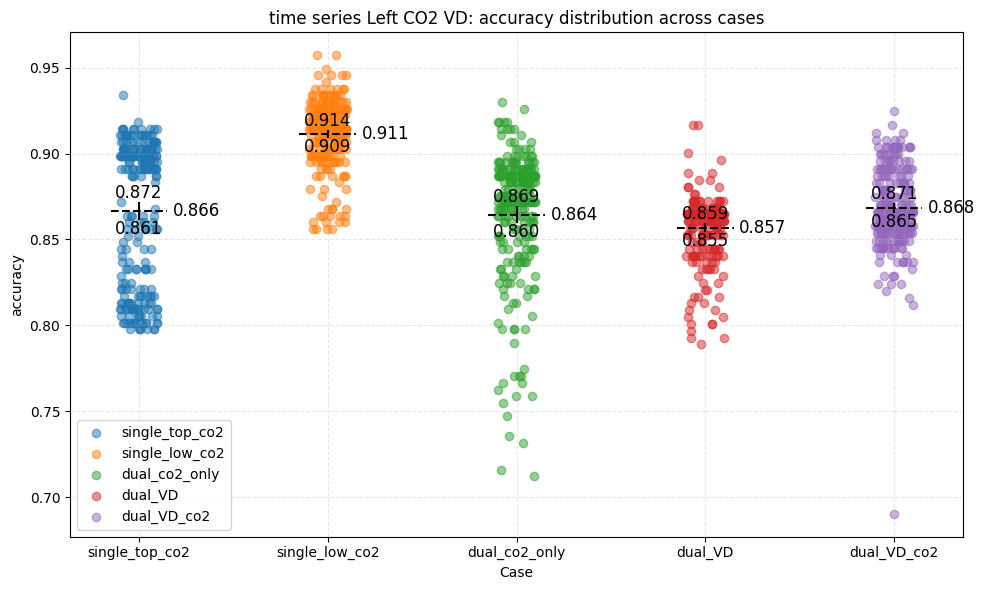

In [35]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

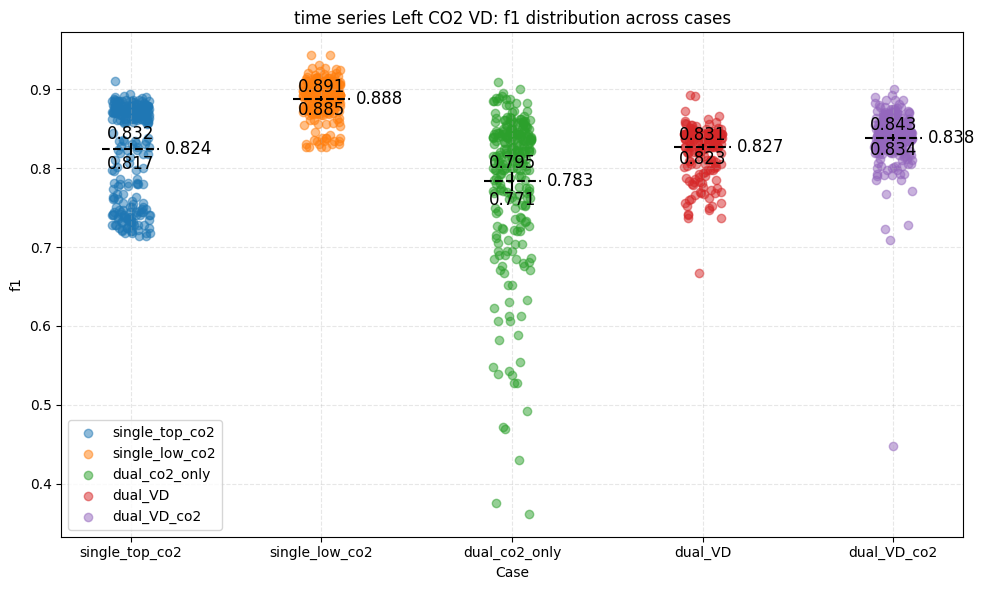

In [36]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

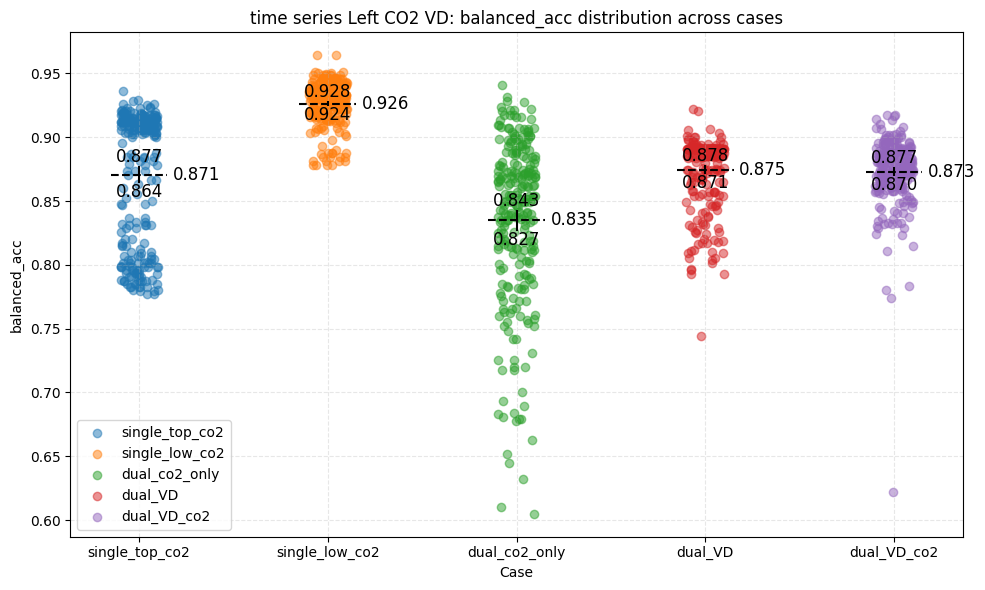

In [37]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

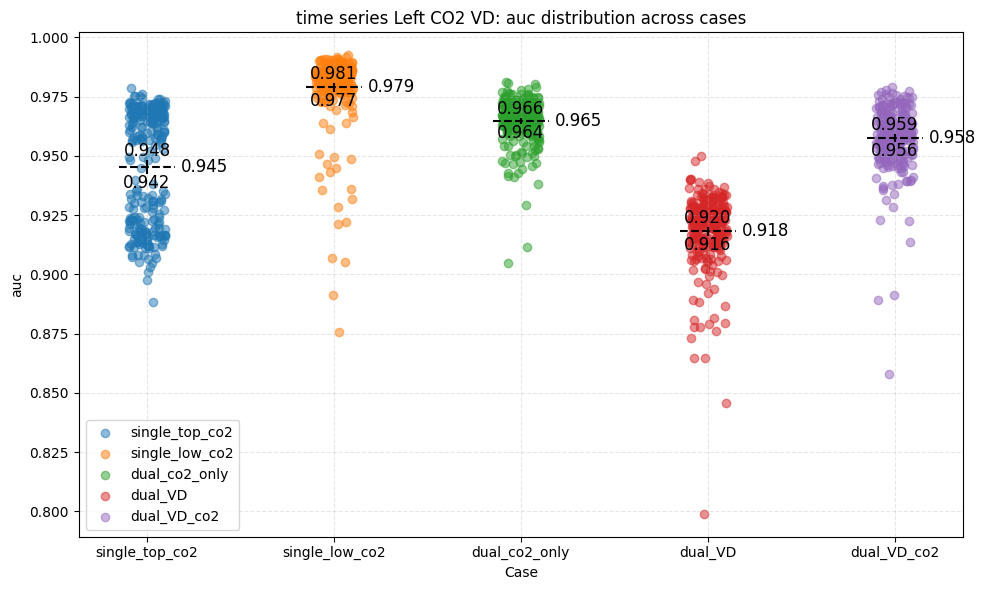

In [38]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series Left CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 17.3157,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 4.9590,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 11.4353,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 19.8225,	5% critical = 0.7750	→	not norm

In [40]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series Left CO2 VD

=== Normality test (D’Agostino and Pearson) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
single_top_co2           :	A² = 19.7677,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 4.1270,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 13.7637,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 24.8236,	5% critical = 0.7750	→	not normal
dual_VD_co2    

In [41]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series Left CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 22.1148,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 5.5118,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 5.4187,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 26.2720,	5% critical = 0.7750

In [42]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series Left CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 15.0087,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 33.2850,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 8.0526,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 9.9825,	5% critical = 0.7750	→	not normal
dual_VD_co2  

### ANOVA

In [43]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series Left CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 610.727868 279.774458 1.683319e-136 0.292075

Effect size (partial η², np2) = 0.2921 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.856940 0.868167 -0.011227 0.001930  -5.817711 472.402919 1.098112e-07 -0.519568
       dual_VD  dual_co2_only 0.856940 0.864420 -0.007480 0.002730  -2.739751 360.796298 5.025344e-02 -0.244682
       dual_VD single_low_co2 0.856940 0.911346 -0.054406 0.001724 -31.565744 497.274986 2.098322e-14 -2.819072
       dual_VD single_top_co2 0.856940 0.866459 -0.009519 0.002883  -3.301909 348.107358 9.310430e-03 -0.294887
   dual_VD_co2  dual_co2_only 0.868167 0.864420  0.003747 0.002885   1.299025 414.684093 6.919761e-01  0.116013
   dual_VD_co2 single_low_co2 0.868167 0.911346 

In [44]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series Left CO2 VD

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 598.956823 254.922294 9.468212e-128 0.266902

Effect size (partial η², np2) = 0.2669 → large effect

=== Games-Howell post-hoc test for f1 ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.827135 0.838498 -0.011363 0.002961  -3.837582 481.446901 1.322280e-03 -0.342727
       dual_VD  dual_co2_only 0.827135 0.783210  0.043925 0.006367   6.898395 296.656784 3.178828e-10  0.616082
       dual_VD single_low_co2 0.827135 0.888191 -0.061056 0.002359 -25.878277 461.055719 9.059420e-14 -2.311136
       dual_VD single_top_co2 0.827135 0.824220  0.002915 0.004279   0.681176 362.944945 9.604423e-01  0.060834
   dual_VD_co2  dual_co2_only 0.838498 0.783210  0.055288 0.006494   8.513999 317.643991 2.287059e-14  0.760368
   dual_VD_co2 single_low_co2 0.838498 0.888191 -0.049693 0.

In [45]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series Left CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 593.905982 348.728486 2.862188e-154 0.327285

Effect size (partial η², np2) = 0.3273 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.874578 0.873130  0.001448 0.002463   0.587737 497.447031 9.768786e-01  0.052490
       dual_VD  dual_co2_only 0.874578 0.834791  0.039787 0.004520   8.803363 336.386040 0.000000e+00  0.786210
       dual_VD single_low_co2 0.874578 0.926389 -0.051811 0.002063 -25.120360 406.819279 9.192647e-14 -2.243448
       dual_VD single_top_co2 0.874578 0.870676  0.003902 0.003735   1.044540 382.097919 8.344082e-01  0.093286
   dual_VD_co2  dual_co2_only 0.873130 0.834791  0.038339 0.004497   8.525391 331.072990 5.773160e-14  0.761385
   dual_VD_co2 single_low_co2 0.873130 0

In [46]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series Left CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F         p-unc     np2
  case      4 608.718745 535.043244 1.258809e-197 0.60446

Effect size (partial η², np2) = 0.6045 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.918159 0.957553 -0.039394 0.001347 -29.237742 486.129972 8.992806e-15 -2.611163
       dual_VD  dual_co2_only 0.918159 0.964773 -0.046614 0.001190 -39.158630 404.340378 7.038814e-14 -3.497177
       dual_VD single_low_co2 0.918159 0.978894 -0.060735 0.001426 -42.602024 497.465676 1.125766e-13 -3.804699
       dual_VD single_top_co2 0.918159 0.945296 -0.027137 0.001847 -14.694209 433.846524 0.000000e+00 -1.312310
   dual_VD_co2  dual_co2_only 0.957553 0.964773 -0.007221 0.001065  -6.782436 443.249182 3.791075e-10 -0.605725
   dual_VD_co2 single_low_co2 0.957553 0.978894 -0.021341 0.

## Time independent - Right

In [47]:
model = "time independent Right CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_room2_righttop_state_timeindep_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeindep_results_raw/case_room2_rightlow_state_timeindep_co2.csv")
dual_co2_only = pd.read_csv("../_timeindep_results_raw/case_room2_right_state_timeindep_co2only.csv")
dual_VD = pd.read_csv("../_timeindep_results_raw/case_room2_right_state_timeindep_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeindep_results_raw/case_room2_right_state_timeindep_VDco2.csv")

In [48]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.965047,0.009781,0.934545,0.960000,0.967273,0.970909,0.989091
f1_weighted,250.0,0.964864,0.009935,0.933207,0.958896,0.966924,0.971059,0.989063
balanced_acc,250.0,0.941737,0.018988,0.877889,0.928943,0.942989,0.956390,0.982671
auc,250.0,0.993132,0.003206,0.973536,0.991463,0.993560,0.995429,0.998741
model_weights.random_forest,250.0,2.250152,0.424640,0.934966,1.962261,2.273562,2.521181,3.255318
model_weights.bagging_svc,250.0,1.927668,0.328380,0.981771,1.681764,1.961725,2.151053,2.761362
model_weights.bagging_knn,250.0,1.866213,0.333192,0.765212,1.652609,1.895462,2.075028,2.818200
model_weights.gradient_boosting,250.0,0.732718,0.476475,-0.605213,0.398320,0.766238,1.046540,2.062774


In [49]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.962036,0.010428,0.934545,0.952727,0.963636,0.970000,0.989091
f1_weighted,250.0,0.961654,0.010662,0.933120,0.952982,0.963086,0.969390,0.989052
balanced_acc,250.0,0.932775,0.020823,0.877889,0.920455,0.932250,0.947773,0.979219
auc,250.0,0.990875,0.004242,0.976761,0.988303,0.991408,0.994014,0.998157
model_weights.random_forest,250.0,2.502817,0.420588,1.239065,2.211993,2.533980,2.811712,3.574115
model_weights.bagging_svc,250.0,1.156022,0.402232,-0.018755,0.862553,1.163042,1.438970,2.207918
model_weights.bagging_knn,250.0,1.967536,0.346702,0.831654,1.747011,1.958556,2.188757,3.312598
model_weights.gradient_boosting,250.0,0.871636,0.548708,-0.766310,0.521171,0.840706,1.230800,2.429754


In [50]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
accuracy,250.0,0.961556,0.010090,0.927273,0.956364,9.600000e-01,0.967273,0.985455
f1_weighted,250.0,0.961236,0.010295,0.927795,0.955636,9.601495e-01,0.967563,0.985455
balanced_acc,250.0,0.933405,0.020140,0.877889,0.918951,9.335356e-01,0.948492,0.975208
auc,250.0,0.993473,0.002697,0.983281,0.991613,9.936975e-01,0.995456,0.998575
model_weights.random_forest,250.0,2.700806,0.365670,1.728873,2.443493,2.679323e+00,2.919088,3.716585
model_weights.bagging_svc,250.0,1.387754,0.418865,-0.089088,1.098218,1.402053e+00,1.645940,2.540388
model_weights.bagging_knn,250.0,1.775367,0.345916,0.959870,1.548128,1.801624e+00,1.986771,2.687038
model_weights.gradient_boosting,250.0,1.297441,0.616214,-0.238019,0.908133,1.312362e+00,1.734373,3.005013


In [51]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.896058,0.015967,0.843636,0.883636,0.894545,0.909091,0.934545
f1_weighted,250.0,0.894308,0.016397,0.836135,0.883183,0.894229,0.907039,0.932509
balanced_acc,250.0,0.823908,0.028143,0.743590,0.805718,0.823613,0.841247,0.895951
auc,250.0,0.930278,0.015376,0.884554,0.919281,0.929574,0.941329,0.966154
model_weights.random_forest,250.0,1.406120,0.267309,0.629414,1.209374,1.395557,1.577179,2.146599
model_weights.bagging_svc,250.0,0.687645,0.357338,-0.153827,0.427127,0.679958,0.938471,1.743050
model_weights.bagging_knn,250.0,0.141581,0.240106,-0.486102,-0.034037,0.128184,0.318376,0.791288
model_weights.gradient_boosting,250.0,2.234317,0.325806,1.406000,2.009731,2.248636,2.427594,3.050703


In [52]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,1.245000e+02,186.750000,249.000000
accuracy,250.0,0.960058,0.010444,0.923636,0.952727,9.600000e-01,0.967273,0.981818
f1_weighted,250.0,0.959719,0.010664,0.921790,0.952457,9.601346e-01,0.967095,0.982052
balanced_acc,250.0,0.930977,0.020550,0.863181,0.915783,9.334016e-01,0.944904,0.980193
auc,250.0,0.993337,0.002731,0.983129,0.991717,9.936800e-01,0.995287,0.998408
model_weights.random_forest,250.0,3.003514,0.404248,2.131813,2.717377,3.037224e+00,3.253359,4.095917
model_weights.bagging_svc,250.0,1.404127,0.381783,0.309419,1.141022,1.439337e+00,1.696683,2.231410
model_weights.bagging_knn,250.0,1.622654,0.368660,0.628218,1.368825,1.634949e+00,1.853675,2.469977
model_weights.gradient_boosting,250.0,1.296735,0.557075,-0.348240,0.895777,1.241294e+00,1.654922,2.754028


In [53]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1_weighted   1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [54]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.978182,0.970909,0.974545,0.96,0.974545
f1_weighted,0.978182,0.971107,0.974623,0.959008,0.974177
balanced_acc,0.964941,0.96091,0.965317,0.916465,0.950755
auc,0.995241,0.993548,0.995763,0.989538,0.998741
x,0,0,0,0,0
x_jitter,0.064088,-0.056037,-0.060568,-0.017457,0.045192


### plot

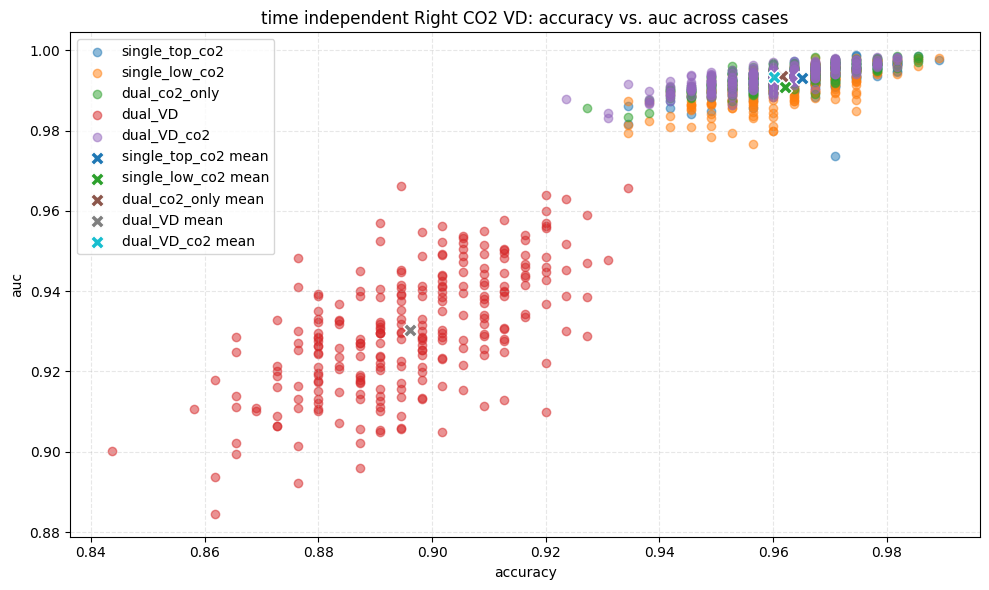

In [55]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

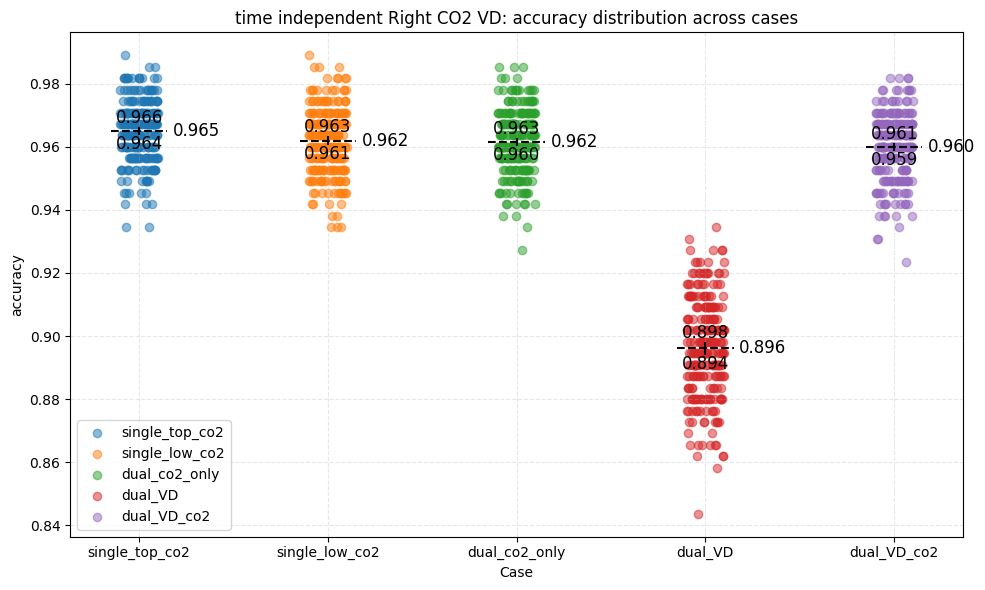

In [56]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

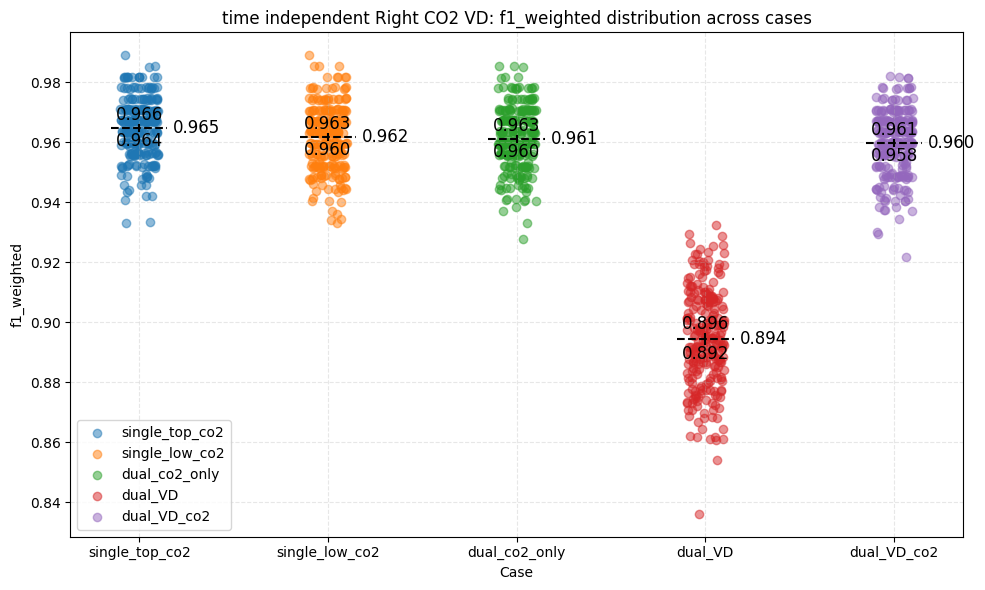

In [57]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

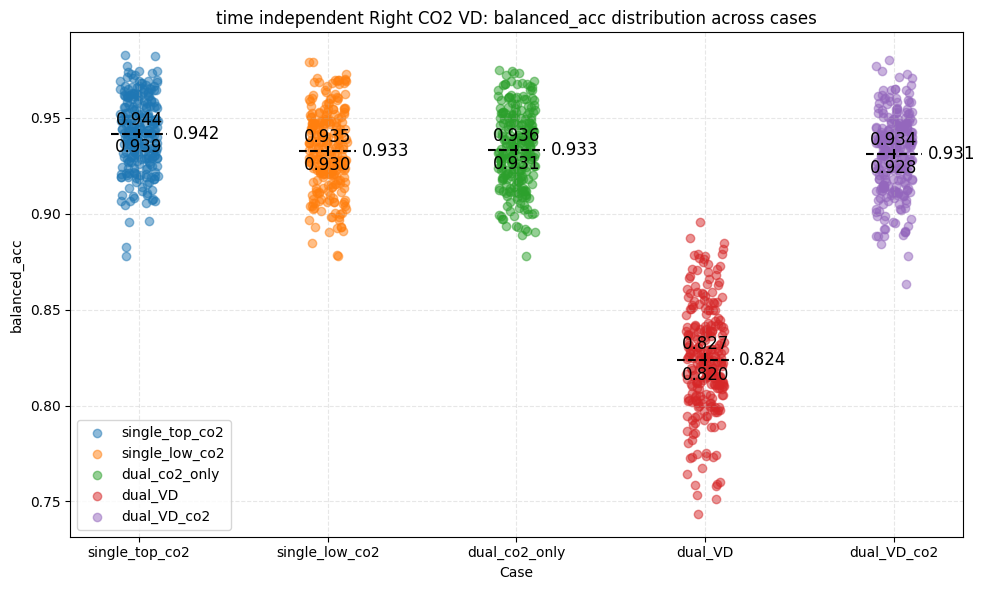

In [58]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

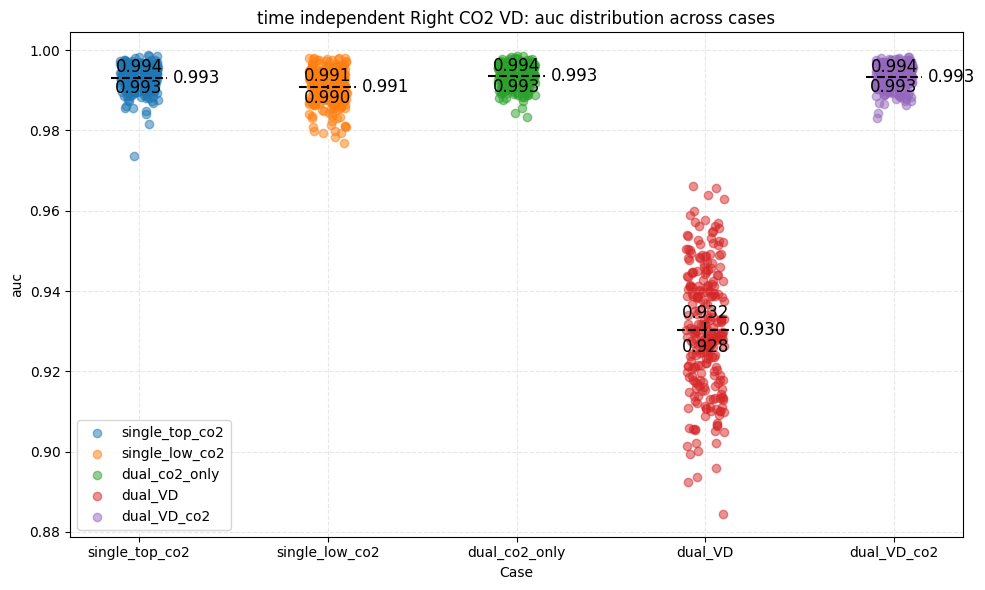

In [59]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent Right CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.1727	→	OK normal
single_low_co2           :	p = 0.4973	→	OK normal
dual_co2_only            :	p = 0.4690	→	OK normal
dual_VD                  :	p = 0.4556	→	OK normal
dual_VD_co2              :	p = 0.0099	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.0012	→	not normal
single_low_co2           :	p = 0.0101	→	not normal
dual_co2_only            :	p = 0.0098	→	not normal
dual_VD                  :	p = 0.0820	→	OK normal
dual_VD_co2              :	p = 0.0001	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 1.9705,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 1.6131,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 1.5482,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.8283,	5% critical = 0.7750	→	not normal

In [61]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent Right CO2 VD

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
single_top_co2           :	p = 0.1336	→	OK normal
single_low_co2           :	p = 0.4306	→	OK normal
dual_co2_only            :	p = 0.4634	→	OK normal
dual_VD                  :	p = 0.5757	→	OK normal
dual_VD_co2              :	p = 0.0069	→	not normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
single_top_co2           :	p = 0.0092	→	not normal
single_low_co2           :	p = 0.1011	→	OK normal
dual_co2_only            :	p = 0.1148	→	OK normal
dual_VD                  :	p = 0.3514	→	OK normal
dual_VD_co2              :	p = 0.0007	→	not normal

=== Normality test (Anderson-Darling) for f1_weighted ===
single_top_co2           :	A² = 1.2799,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 0.9423,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 0.8221,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.2708,	5% critical = 0.7750	→	OK 

In [62]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent Right CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.0835	→	OK normal
single_low_co2           :	p = 0.1126	→	OK normal
dual_co2_only            :	p = 0.0397	→	not normal
dual_VD                  :	p = 0.7636	→	OK normal
dual_VD_co2              :	p = 0.2031	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.0154	→	not normal
single_low_co2           :	p = 0.1581	→	OK normal
dual_co2_only            :	p = 0.1155	→	OK normal
dual_VD                  :	p = 0.2700	→	OK normal
dual_VD_co2              :	p = 0.2334	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 0.7056,	5% critical = 0.7750	→	OK normal
single_low_co2           :	A² = 0.4463,	5% critical = 0.7750	→	OK normal
dual_co2_only            :	A² = 0.4090,	5% critical = 0.7750	→	OK normal
dual_VD                  :	A² = 0.4785,	5% critical = 0.7750	→	OK n

In [63]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent Right CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0001	→	not normal
dual_co2_only            :	p = 0.0007	→	not normal
dual_VD                  :	p = 0.3583	→	OK normal
dual_VD_co2              :	p = 0.0004	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0003	→	not normal
dual_VD                  :	p = 0.5344	→	OK normal
dual_VD_co2              :	p = 0.0002	→	not normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 2.2641,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 1.5291,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 1.1189,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 0.3699,	5% critical = 0.7750	→	OK normal
dual_VD_co2 

### ANOVA

In [64]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent Right CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 619.566395 980.418491 2.752146e-266 0.840215

Effect size (partial η², np2) = 0.8402 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.896058 0.960058 -0.064000 0.001207 -53.038228 429.097264 1.967315e-13 -4.736735
       dual_VD  dual_co2_only 0.896058 0.961556 -0.065498 0.001195 -54.829408 420.523864 1.029177e-13 -4.896702
       dual_VD single_low_co2 0.896058 0.962036 -0.065978 0.001206 -54.702879 428.712985 3.208545e-14 -4.885402
       dual_VD single_top_co2 0.896058 0.965047 -0.068989 0.001184 -58.256145 412.800559 1.089129e-13 -5.202737
   dual_VD_co2  dual_co2_only 0.960058 0.961556 -0.001498 0.000918  -1.631208 497.410309 4.780841e-01 -0.145680
   dual_VD_co2 single_low_co2 0.960058 0.9

In [65]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent Right CO2 VD

=== Welch ANOVA for f1_weighted ===
Source  ddof1     ddof2          F         p-unc     np2
  case      4 619.48335 972.583202 2.460976e-265 0.84001

Effect size (partial η², np2) = 0.8400 → large effect

=== Games-Howell post-hoc test for f1_weighted ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.894308 0.959719 -0.065412 0.001237 -52.876186 427.672313 5.795364e-14 -4.722264
       dual_VD  dual_co2_only 0.894308 0.961236 -0.066928 0.001224 -54.658100 418.902254 0.000000e+00 -4.881403
       dual_VD single_low_co2 0.894308 0.961654 -0.067346 0.001237 -54.442874 427.632332 0.000000e+00 -4.862181
       dual_VD single_top_co2 0.894308 0.964864 -0.070556 0.001213 -58.187786 410.115246 8.282264e-14 -5.196632
   dual_VD_co2  dual_co2_only 0.959719 0.961236 -0.001517 0.000937  -1.618153 497.382747 4.864172e-01 -0.144514
   dual_VD_co2 single_low_co2 0.959719 0

In [66]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent Right CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 620.463716 872.553983 4.578509e-253 0.804476

Effect size (partial η², np2) = 0.8045 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.823908 0.930977 -0.107070 0.002204 -48.581127 455.745092 0.000000e+00 -4.338681
       dual_VD  dual_co2_only 0.823908 0.933405 -0.109497 0.002189 -50.027093 451.043523 0.000000e+00 -4.467817
       dual_VD single_low_co2 0.823908 0.932775 -0.108868 0.002214 -49.168357 458.763839 1.534328e-13 -4.391125
       dual_VD single_top_co2 0.823908 0.941737 -0.117830 0.002147 -54.876860 436.776426 2.381428e-13 -4.900940
   dual_VD_co2  dual_co2_only 0.930977 0.933405 -0.002427 0.001820  -1.333791 497.798070 6.702134e-01 -0.119118
   dual_VD_co2 single_low_co2 0.93

In [67]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent Right CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2           F         p-unc     np2
  case      4 609.336192 1045.393767 3.779790e-271 0.91816

Effect size (partial η², np2) = 0.9182 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.930278 0.993337 -0.063059 0.000988 -63.846732 264.694246 0.000000e+00 -5.702021
       dual_VD  dual_co2_only 0.930278 0.993473 -0.063195 0.000987 -64.009131 264.303476 2.586820e-14 -5.716524
       dual_VD single_low_co2 0.930278 0.990875 -0.060598 0.001009 -60.071039 286.684422 0.000000e+00 -5.364821
       dual_VD single_top_co2 0.930278 0.993132 -0.062854 0.000993 -63.274428 270.609159 0.000000e+00 -5.650909
   dual_VD_co2  dual_co2_only 0.993337 0.993473 -0.000136 0.000243  -0.561425 497.920562 9.804804e-01 -0.050140
   dual_VD_co2 single_low_co2 0.993337 0.990875  0.0

## Time series - Right

In [68]:
model = "time series Right CO2 VD"
single_top_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_room2_righttop_state_timeseries_co2.csv")
single_low_co2 = pd.read_csv("../../analysis_sensor_position/_timeseries_results_raw/case_room2_rightlow_state_timeseries_co2.csv")
dual_co2_only = pd.read_csv("../_timeseries_results_raw/case_room2_right_state_timeseries_co2only.csv")
dual_VD = pd.read_csv("../_timeseries_results_raw/case_room2_right_state_timeseries_VD.csv")
dual_VD_co2 = pd.read_csv("../_timeseries_results_raw/case_room2_right_state_timeseries_VDco2.csv")

In [69]:
single_top_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,6.225000e+01,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,6.225000e+01,124.500000,186.750000,249.000000
accuracy,250.0,0.775251,0.104519,0.621514,6.334661e-01,0.828685,0.856574,0.940239
f1,250.0,0.532135,0.373404,0.000000,0.000000e+00,0.759375,0.828499,0.922280
balanced_acc,250.0,0.730211,0.169050,0.500000,5.000000e-01,0.810381,0.874487,0.945960
auc,250.0,0.923129,0.038525,0.834017,9.000889e-01,0.930168,0.946455,0.985576
feature_importance.righttop_CO2_scaled,250.0,0.050429,0.065128,-0.016733,-1.110223e-16,0.021116,0.090139,0.298008
feature_importance.righttop_CO2_fd1_scaled,250.0,0.045893,0.087000,-0.022311,-1.110223e-16,0.007968,0.026494,0.400000
feature_importance.righttop_CO2_fd2_scaled,250.0,0.039232,0.075297,-0.039841,-1.110223e-16,0.006574,0.029283,0.361753
feature_importance.righttop_CO2_fd3_scaled,250.0,0.034433,0.069488,-0.041434,-1.110223e-16,0.004582,0.026992,0.355777


In [70]:
single_low_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.894375,0.022138,0.852590,0.888446,0.900398,0.908367,0.956175
f1,250.0,0.871927,0.024202,0.826291,0.862939,0.878638,0.887805,0.941176
balanced_acc,250.0,0.911774,0.019422,0.874487,0.905079,0.917231,0.924528,0.956248
auc,250.0,0.965501,0.019819,0.886109,0.962734,0.972860,0.976945,0.990156
feature_importance.rightlow_CO2_scaled,250.0,0.005519,0.008064,-0.017131,0.000498,0.003984,0.009064,0.037849
feature_importance.rightlow_CO2_fd1_scaled,250.0,0.127535,0.069624,-0.005578,0.111355,0.148008,0.170418,0.273705
feature_importance.rightlow_CO2_fd2_scaled,250.0,0.099372,0.058411,-0.005976,0.073606,0.110956,0.140239,0.278486
feature_importance.rightlow_CO2_fd3_scaled,250.0,0.067822,0.046226,-0.012351,0.034661,0.071514,0.103386,0.196016


In [71]:
dual_co2_only.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,6.225000e+01,1.245000e+02,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,6.225000e+01,1.245000e+02,186.750000,249.000000
accuracy,250.0,0.821743,0.093415,0.622568,7.898833e-01,8.365759e-01,0.902724,0.945525
f1,250.0,0.657509,0.308852,0.000000,6.351975e-01,7.692308e-01,0.877415,0.927835
balanced_acc,250.0,0.787916,0.149071,0.494466,7.290267e-01,8.198287e-01,0.917210,0.952767
auc,250.0,0.946021,0.030319,0.846047,9.312747e-01,9.434783e-01,0.977454,0.987813
feature_importance.rightlow_CO2_scaled,250.0,0.003125,0.012377,-0.031128,-2.723735e-03,-1.110223e-16,0.006128,0.065759
feature_importance.rightlow_CO2_fd1_scaled,250.0,0.070864,0.086741,-0.007004,4.669261e-03,1.673152e-02,0.144066,0.314397
feature_importance.rightlow_CO2_fd2_scaled,250.0,0.049753,0.064857,-0.012840,6.225681e-03,1.848249e-02,0.082685,0.302335
feature_importance.rightlow_CO2_fd3_scaled,250.0,0.029689,0.042137,-0.010117,3.112840e-03,1.167315e-02,0.032879,0.226070


In [72]:
dual_VD.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.730482,0.071302,0.612245,0.642857,0.751020,0.791837,0.832653
f1,250.0,0.494167,0.299553,0.000000,0.217851,0.645205,0.724094,0.791878
balanced_acc,250.0,0.679700,0.118204,0.492363,0.549446,0.721014,0.778870,0.835678
auc,250.0,0.821913,0.054566,0.440963,0.784225,0.841148,0.861626,0.888036
feature_importance.right_CO2_vd_scaled,250.0,-0.002127,0.010842,-0.037551,-0.006531,0.000000,0.003265,0.026122
feature_importance.right_CO2_vd_fd1_scaled,250.0,0.043716,0.044327,-0.040408,0.000000,0.035102,0.070102,0.221633
feature_importance.right_CO2_vd_fd2_scaled,250.0,0.071221,0.066827,-0.026122,0.000000,0.060816,0.125102,0.253061
feature_importance.right_CO2_vd_fd3_scaled,250.0,0.075672,0.066572,-0.012245,0.008265,0.066735,0.123571,0.253469


In [73]:
dual_VD_co2.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
random_seed,250.0,124.500000,72.312977,0.000000,62.250000,124.500000,186.750000,249.000000
accuracy,250.0,0.896887,0.021813,0.824268,0.887029,0.899582,0.912134,0.945607
f1,250.0,0.877058,0.026482,0.734177,0.866995,0.882051,0.894205,0.933333
balanced_acc,250.0,0.907889,0.022852,0.788007,0.898699,0.912600,0.922471,0.953749
auc,250.0,0.962909,0.015644,0.875702,0.961254,0.968205,0.972401,0.979814
feature_importance.right_CO2_vd_scaled,250.0,0.001657,0.006588,-0.014226,-0.002092,0.001255,0.004184,0.043515
feature_importance.right_CO2_vd_fd1_scaled,250.0,0.017759,0.014956,-0.012134,0.005544,0.016736,0.025523,0.071967
feature_importance.right_CO2_vd_fd2_scaled,250.0,0.015339,0.016410,-0.018410,0.001360,0.013180,0.026255,0.068619
feature_importance.right_CO2_vd_fd3_scaled,250.0,0.011781,0.013797,-0.022176,0.002092,0.009623,0.019665,0.056904


In [74]:
single_top_co2['case'] = 'single_top_co2'
single_low_co2['case'] = 'single_low_co2'
dual_co2_only['case'] = 'dual_co2_only'
dual_VD['case'] = 'dual_VD'
dual_VD_co2['case'] = 'dual_VD_co2'

metrics = ["case", "accuracy", "f1", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        single_top_co2[metrics],
        single_low_co2[metrics],
        dual_co2_only[metrics],
        dual_VD[metrics],
        dual_VD_co2[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          1250 non-null   object 
 1   accuracy      1250 non-null   float64
 2   f1            1250 non-null   float64
 3   balanced_acc  1250 non-null   float64
 4   auc           1250 non-null   float64
dtypes: float64(4), object(1)
memory usage: 49.0+ KB


In [75]:
case_order = ['single_top_co2', 'single_low_co2', 'dual_co2_only', 'dual_VD', 'dual_VD_co2']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,single_top_co2,single_top_co2,single_top_co2,single_top_co2,single_top_co2
accuracy,0.633466,0.940239,0.848606,0.876494,0.816733
f1,0.0,0.92228,0.802083,0.85446,0.722892
balanced_acc,0.5,0.94596,0.846151,0.900226,0.782062
auc,0.846527,0.985439,0.925144,0.981064,0.942439
x,0,0,0,0,0
x_jitter,-0.091799,-0.050886,-0.050591,0.033293,-0.075326


### plot

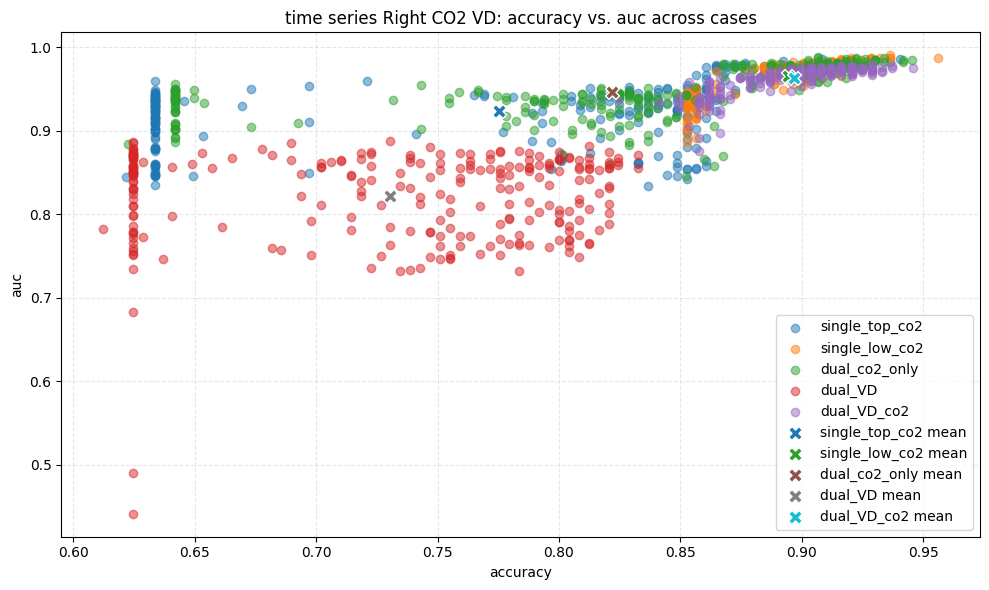

In [76]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

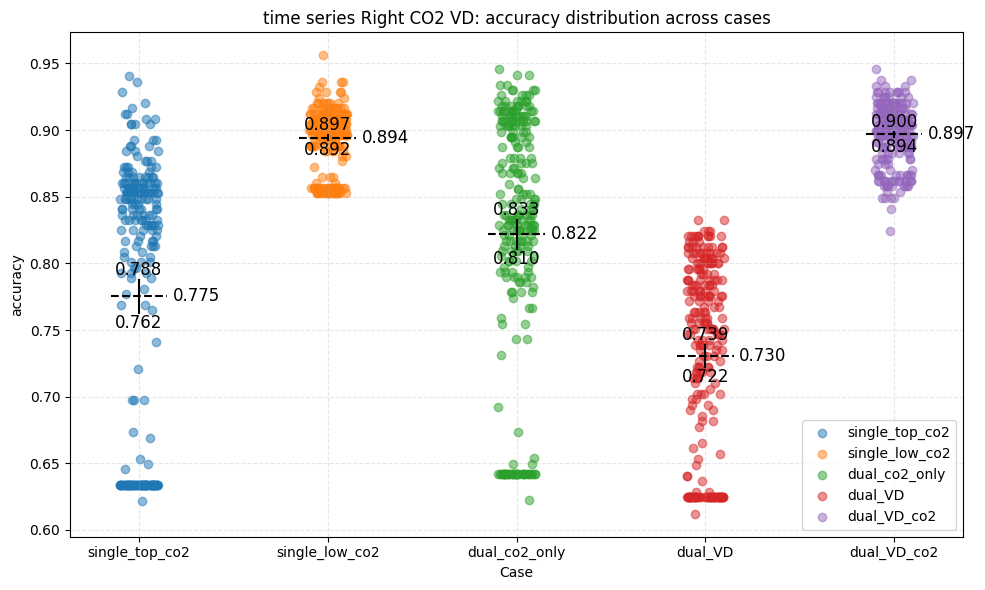

In [77]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

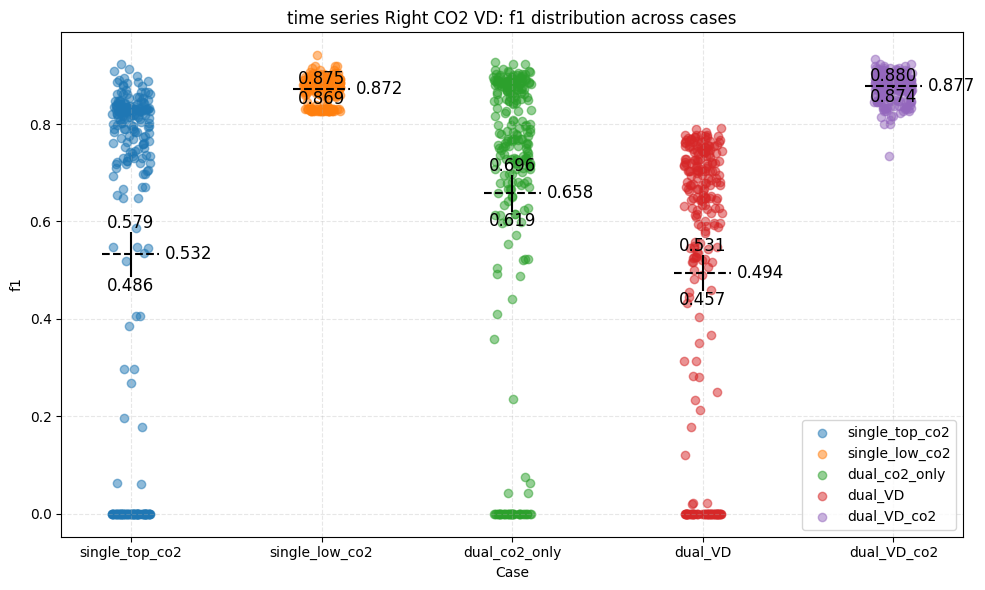

In [78]:
# plot f1 score
metric = "f1"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

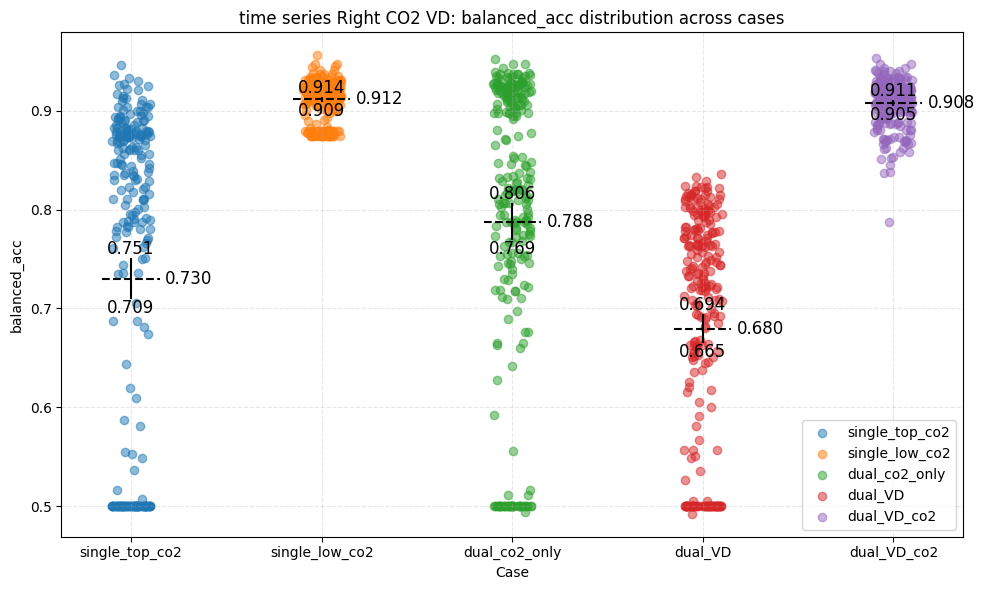

In [79]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

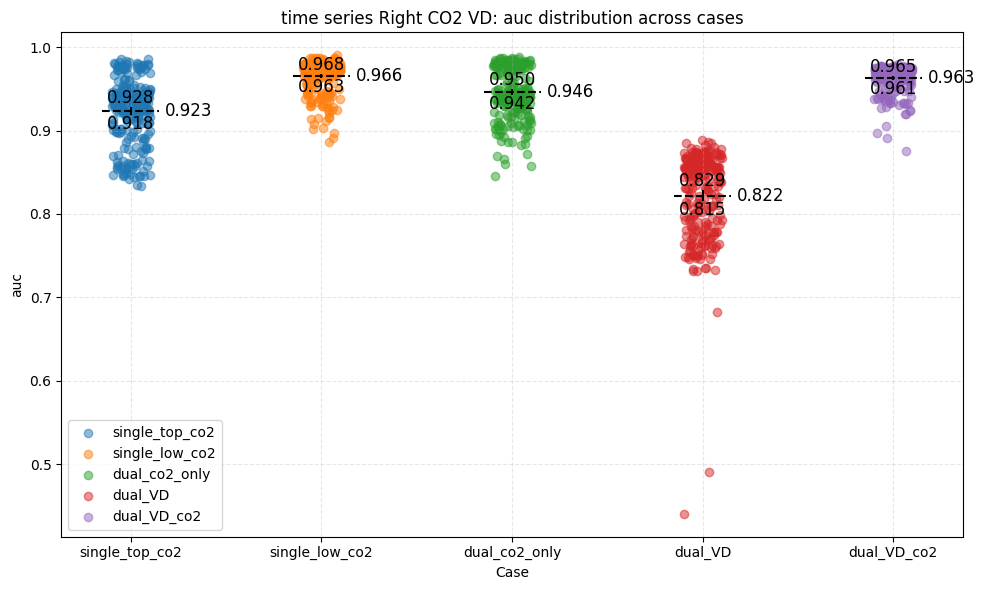

In [80]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time series Right CO2 VD

=== Normality test (D’Agostino and Pearson) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0001	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0010	→	not normal

=== Normality test (Shapiro-Wilk) for accuracy ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for accuracy ===
single_top_co2           :	A² = 23.2172,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 12.9484,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 12.1684,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 11.6746,	5% critical = 0.7750	→	not no

In [82]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1',
    group_order=case_order
)

time series Right CO2 VD

=== Normality test (D’Agostino and Pearson) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0003	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for f1 ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for f1 ===
single_top_co2           :	A² = 32.1503,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 11.3988,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 29.2108,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 25.6967,	5% critical = 0.7750	→	not normal
dual_VD_co2  

In [83]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time series Right CO2 VD

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for balanced_acc ===
single_top_co2           :	A² = 23.2345,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 11.7421,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 15.0270,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 13.9986,	5% critical = 0.7

In [84]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time series Right CO2 VD

=== Normality test (D’Agostino and Pearson) for auc ===
single_top_co2           :	p = 0.0004	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0009	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
single_top_co2           :	p = 0.0000	→	not normal
single_low_co2           :	p = 0.0000	→	not normal
dual_co2_only            :	p = 0.0000	→	not normal
dual_VD                  :	p = 0.0000	→	not normal
dual_VD_co2              :	p = 0.0000	→	not normal

=== Normality test (Anderson-Darling) for auc ===
single_top_co2           :	A² = 4.5665,	5% critical = 0.7750	→	not normal
single_low_co2           :	A² = 20.2452,	5% critical = 0.7750	→	not normal
dual_co2_only            :	A² = 5.1055,	5% critical = 0.7750	→	not normal
dual_VD                  :	A² = 8.7296,	5% critical = 0.7750	→	not normal
dual_VD_co2  

### ANOVA

In [85]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time series Right CO2 VD

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 582.745785 419.244426 6.946836e-170 0.455249

Effect size (partial η², np2) = 0.4552 → large effect

=== Games-Howell post-hoc test for accuracy ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.730482 0.896887 -0.166405 0.004716 -35.286633 295.202209 0.000000e+00 -3.151377
       dual_VD  dual_co2_only 0.730482 0.821743 -0.091262 0.007432 -12.278846 465.612053 5.462297e-14 -1.096599
       dual_VD single_low_co2 0.730482 0.894375 -0.163893 0.004722 -34.709198 296.566808 1.214584e-13 -3.099807
       dual_VD single_top_co2 0.730482 0.775251 -0.044769 0.008002  -5.594726 439.500388 3.875754e-07 -0.499653
   dual_VD_co2  dual_co2_only 0.896887 0.821743  0.075144 0.006067  12.385697 276.072743 3.863576e-14  1.106141
   dual_VD_co2 single_low_co2 0.896887 0.894375

In [86]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1'
)

time series Right CO2 VD

=== Welch ANOVA for f1 ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 569.970349 182.927728 9.925352e-101 0.289689

Effect size (partial η², np2) = 0.2897 → large effect

=== Games-Howell post-hoc test for f1 ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.494167 0.877058 -0.382891 0.019019 -20.131724 252.891917 0.000000e+00 -1.797923
       dual_VD  dual_co2_only 0.494167 0.657509 -0.163342 0.027212  -6.002611 497.535281 3.738247e-08 -0.536081
       dual_VD single_low_co2 0.494167 0.871927 -0.377760 0.019007 -19.874675 252.250733 0.000000e+00 -1.774966
       dual_VD single_top_co2 0.494167 0.532135 -0.037967 0.030276  -1.254034 475.629366 7.194749e-01 -0.111995
   dual_VD_co2  dual_co2_only 0.877058 0.657509  0.219548 0.019605  11.198486 252.661107 7.660539e-15  1.000114
   dual_VD_co2 single_low_co2 0.877058 0.871927  0.005130 0

In [87]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time series Right CO2 VD

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 572.259812 339.629255 1.547868e-149 0.399751

Effect size (partial η², np2) = 0.3998 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.679700 0.907889 -0.228189 0.007614 -29.968388 267.586598 1.240119e-13 -2.676415
       dual_VD  dual_co2_only 0.679700 0.787916 -0.108216 0.012032  -8.993790 473.405355 2.262635e-13 -0.803217
       dual_VD single_low_co2 0.679700 0.911774 -0.232074 0.007576 -30.632234 262.435002 0.000000e+00 -2.735702
       dual_VD single_top_co2 0.679700 0.730211 -0.050511 0.013046  -3.871741 445.507446 1.169443e-03 -0.345777
   dual_VD_co2  dual_co2_only 0.907889 0.787916  0.119973 0.009538  12.578116 260.696297 0.000000e+00  1.123326
   dual_VD_co2 single_low_co2 0.907889 

In [88]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time series Right CO2 VD

=== Welch ANOVA for auc ===
Source  ddof1      ddof2          F         p-unc      np2
  case      4 598.715997 450.026185 8.078370e-179 0.702335

Effect size (partial η², np2) = 0.7023 → large effect

=== Games-Howell post-hoc test for auc ===
             A              B  mean(A)  mean(B)      diff       se          T         df         pval    hedges
       dual_VD    dual_VD_co2 0.821913 0.962909 -0.140996 0.003590 -39.273642 289.659700 9.203749e-14 -3.507448
       dual_VD  dual_co2_only 0.821913 0.946021 -0.124108 0.003948 -31.435345 389.373076 0.000000e+00 -2.807426
       dual_VD single_low_co2 0.821913 0.965501 -0.143588 0.003672 -39.106993 313.576193 3.108624e-15 -3.492565
       dual_VD single_top_co2 0.821913 0.923129 -0.101216 0.004225 -23.959298 447.831003 1.990630e-13 -2.139756
   dual_VD_co2  dual_co2_only 0.962909 0.946021  0.016889 0.002158   7.826841 372.808769 7.874812e-13  0.698999
   dual_VD_co2 single_low_co2 0.962909 0.965501 -0.002591